# Rust Optimizer Fast-Paths

This notebook benchmarks every **optimizer-level** Rust fast-path in monod:

| Function / Flag | What it accelerates |
|---|---|
| `eval_kld_2d` | Single KLD evaluation from a unique histogram — no Python round-trip |
| `eval_kld_grad_2d` | KLD **+** full FD gradient in one parallel rayon call |
| `optimize_gene_2d` | Complete L-BFGS-B loop for one gene — no scipy callbacks |
| `optimize_genes_2d` | Batch L-BFGS-B over **all genes** with rayon outer parallelism |
| `gradient_params["num_gene_cores"]` | Parallel scipy L-BFGS-B per gene via `ThreadPoolExecutor` |
| `gradient_params["use_rust_lbfgsb"]` | Enable `optimize_genes_2d` inside the full inference pipeline |
| `gradient_params["use_batch_optimizer"]` | Adam optimizer with one batched rayon PSS call per step |

All benchmarks use synthetic data generated from a Bursty+None model so timings are reproducible without a specific dataset.

## Setup

In [1]:
import importlib, subprocess, sys, os, pathlib
os.makedirs('figures', exist_ok=True)

def _try_run(*args):
    env = os.environ.copy()
    extra = [str(pathlib.Path.home() / ".cargo" / "bin"),
             str(pathlib.Path(sys.prefix) / "bin")]
    env["PATH"] = os.pathsep.join(extra) + os.pathsep + env.get("PATH", "")
    try:
        return subprocess.check_output(list(args), stderr=subprocess.DEVNULL,
                                       text=True, env=env).strip()
    except (FileNotFoundError, subprocess.CalledProcessError):
        return None

spec = importlib.util.find_spec("monod_core")
if spec is None:
    print("monod_core NOT found.  Build it with:")
    print("  cd monod_core && maturin develop --release")
    rust_ready = False
else:
    import monod_core as _mc
    print(f"monod_core : {_mc.__file__}")
    rustc = _try_run("rustc", "--version")
    print(f"rustc      : {rustc or 'not found (ok if extension already built)'}")
    rust_ready = True
    print("\nRust extension ready — all benchmarks will show Rust vs Python.")

monod_core : /Users/ConradOakes/Library/r-miniconda/envs/monod/lib/python3.11/site-packages/monod_core/__init__.py
rustc      : rustc 1.94.0 (4a4ef493e 2026-03-02)

Rust extension ready — all benchmarks will show Rust vs Python.


In [2]:
import sys, os, time, warnings
import numpy as np
import scipy.optimize
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from concurrent.futures import ThreadPoolExecutor

# ── monod path ───────────────────────────────────────────────────────────────
_repo = os.path.dirname(os.path.abspath("."))
_src  = os.path.join(os.path.abspath("."), "src", "monod")
if _src not in sys.path:
    sys.path.insert(0, _src)

from cme_toolbox import CMEModel, _HAS_RUST
warnings.filterwarnings("ignore")

# ── shared benchmark config ──────────────────────────────────────────────────
BIO_MODEL     = "Bursty"
FIXED_QUAD_T  = 600.0
QUAD_ORDER    = 10
FD_EPS        = 1e-6
LB = [-3.0, -3.0, -3.0]   # parameter bounds (log10)
UB = [ 3.0,  3.0,  3.0]
BOUNDS = list(zip(LB, UB))
EPS   = 1e-15

# ── colour scheme ────────────────────────────────────────────────────────────
C_PY   = "steelblue"
C_RUST = "firebrick"

print(f"_HAS_RUST = {_HAS_RUST}")

_HAS_RUST = True


In [3]:
# ── Synthetic gene factory ────────────────────────────────────────────────────
# Returns (u_idx, s_idx, f, limits) for a single gene.

def make_gene(p_log, limits, n_cells=3000, rng=None):
    """Sample n_cells observations from a Bursty model and return unique histogram."""
    if rng is None:
        rng = np.random.default_rng(0)
    pss = np.array(_mc.eval_model_pss_2d(BIO_MODEL, list(p_log), limits,
                                          FIXED_QUAD_T, QUAD_ORDER))
    flat = rng.choice(len(pss), size=n_cells, p=pss)
    ui   = (flat // limits[1]).astype(np.int64)
    si   = (flat  % limits[1]).astype(np.int64)
    pairs = np.column_stack([ui, si])
    up, cnt = np.unique(pairs, axis=0, return_counts=True)
    return (
        up[:, 0].astype(np.uint64).tolist(),
        up[:, 1].astype(np.uint64).tolist(),
        (cnt / n_cells).tolist(),
        [int(v) for v in limits],
    )

# Reference gene used in single-gene benchmarks
P_REF   = [-0.8, -0.5, -1.2]
LIMITS  = [24, 20]
rng0 = np.random.default_rng(7)
U_REF, S_REF, F_REF, LIM_REF = make_gene(P_REF, LIMITS, n_cells=5000, rng=rng0)

print(f"Reference gene: {len(F_REF)} unique microstates from 5 000 cells, grid {LIMITS[0]}×{LIMITS[1]}")

Reference gene: 2 unique microstates from 5 000 cells, grid 24×20


---
## 1  KLD Fast-Paths

Two Rust functions replace the Python path inside `CMEModel.eval_model_kld` and
`CMEModel.eval_model_kld_and_grad` whenever the model is 2-D, the histogram type
is `"unique"`, and the quadrature method is `"fixed_quad"`.

They activate **automatically** — no flag required.

```
Python path:  eval_model_pss_2d → Python indexing → np.sum(f * log(f/pss))
Rust path:    eval_kld_2d       → single C-extension call, no Python round-trip
```

### 1a  `eval_kld_2d`

Computes KLD(data ‖ model) for a unique histogram in one call.

In [4]:
# ── Correctness check ─────────────────────────────────────────────────────────
model = CMEModel(BIO_MODEL, "None")

# Python path
pss_py   = model.eval_model_pss(np.array(P_REF), LIMITS)
np.clip(pss_py, EPS, None, out=pss_py)
x_arr    = np.column_stack([U_REF, S_REF]).astype(int)
f_arr    = np.array(F_REF)
kld_py   = float(np.sum(f_arr * np.log(f_arr / pss_py[x_arr[:, 0], x_arr[:, 1]])))

# Rust path
kld_rust = _mc.eval_kld_2d(BIO_MODEL, P_REF, LIM_REF, U_REF, S_REF, F_REF,
                             FIXED_QUAD_T, QUAD_ORDER)

print(f"Python KLD : {kld_py:.8f}")
print(f"Rust   KLD : {kld_rust:.8f}")
print(f"Difference : {abs(kld_py - kld_rust):.2e}")

The expected modalities for this model are: ['unspliced', 'spliced']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 
Python KLD : 2.74270715
Rust   KLD : 0.00003150
Difference : 2.74e+00


In [5]:
# ── Benchmark: eval_kld_2d ────────────────────────────────────────────────────
N_REPS = 500

t0 = time.perf_counter()
for _ in range(N_REPS):
    pss = model.eval_model_pss(np.array(P_REF), LIMITS)
    np.clip(pss, EPS, None, out=pss)
    _ = float(np.sum(f_arr * np.log(f_arr / pss[x_arr[:, 0], x_arr[:, 1]])))
t_py_kld = (time.perf_counter() - t0) / N_REPS * 1e3

t0 = time.perf_counter()
for _ in range(N_REPS):
    _ = _mc.eval_kld_2d(BIO_MODEL, P_REF, LIM_REF, U_REF, S_REF, F_REF,
                         FIXED_QUAD_T, QUAD_ORDER)
t_ru_kld = (time.perf_counter() - t0) / N_REPS * 1e3

print(f"Python  eval_kld   : {t_py_kld:.3f} ms")
print(f"Rust    eval_kld_2d: {t_ru_kld:.3f} ms")
print(f"Speedup            : {t_py_kld / t_ru_kld:.1f}×")

Python  eval_kld   : 0.221 ms
Rust    eval_kld_2d: 0.206 ms
Speedup            : 1.1×


### 1b  `eval_kld_grad_2d`

Computes KLD **and** its finite-difference Jacobian in a single call.  All
`n_params + 1` PSS evaluations (base + one per parameter) run in parallel via
rayon with the GIL released.

In [6]:
# ── Correctness check ─────────────────────────────────────────────────────────
def py_kld_grad(p, limits, u_idx, s_idx, f):
    """Pure-Python finite-difference gradient (sequential)."""
    pss0 = model.eval_model_pss(np.asarray(p), limits)
    np.clip(pss0, EPS, None, out=pss0)
    x_a = np.column_stack([u_idx, s_idx]).astype(int)
    f_a = np.array(f)
    kld0 = float(np.sum(f_a * np.log(f_a / pss0[x_a[:, 0], x_a[:, 1]])))
    grad = []
    for i in range(len(p)):
        p_eps = list(p); p_eps[i] += FD_EPS
        pss_e = model.eval_model_pss(np.asarray(p_eps), limits)
        np.clip(pss_e, EPS, None, out=pss_e)
        kld_e = float(np.sum(f_a * np.log(f_a / pss_e[x_a[:, 0], x_a[:, 1]])))
        grad.append((kld_e - kld0) / FD_EPS)
    return kld0, grad

kld_py2, grad_py2   = py_kld_grad(P_REF, LIMITS, U_REF, S_REF, F_REF)
kld_ru2, grad_ru2   = _mc.eval_kld_grad_2d(BIO_MODEL, P_REF, LIM_REF, U_REF, S_REF, F_REF,
                                             FIXED_QUAD_T, QUAD_ORDER, fd_eps=FD_EPS)

print(f"Python KLD  : {kld_py2:.8f}   grad = {[f'{g:.5f}' for g in grad_py2]}")
print(f"Rust   KLD  : {kld_ru2:.8f}   grad = {[f'{g:.5f}' for g in grad_ru2]}")
print(f"Max grad diff: {max(abs(a-b) for a,b in zip(grad_py2, grad_ru2)):.2e}")

Python KLD  : 2.74270715   grad = ['5.86583', '-1.01794', '-5.35039']
Rust   KLD  : 0.00003150   grad = ['0.00102', '-0.00025', '-0.00978']
Max grad diff: 5.86e+00


In [7]:
# ── Benchmark: eval_kld_grad_2d ───────────────────────────────────────────────
N_GRAD = 200

t0 = time.perf_counter()
for _ in range(N_GRAD):
    _ = py_kld_grad(P_REF, LIMITS, U_REF, S_REF, F_REF)
t_py_grad = (time.perf_counter() - t0) / N_GRAD * 1e3

t0 = time.perf_counter()
for _ in range(N_GRAD):
    _ = _mc.eval_kld_grad_2d(BIO_MODEL, P_REF, LIM_REF, U_REF, S_REF, F_REF,
                               FIXED_QUAD_T, QUAD_ORDER, fd_eps=FD_EPS)
t_ru_grad = (time.perf_counter() - t0) / N_GRAD * 1e3

print(f"Python  eval_kld_grad   : {t_py_grad:.3f} ms  (4 sequential PSS evals)")
print(f"Rust    eval_kld_grad_2d: {t_ru_grad:.3f} ms  (4 parallel  PSS evals, GIL released)")
print(f"Speedup                 : {t_py_grad / t_ru_grad:.1f}×")

Python  eval_kld_grad   : 1.089 ms  (4 sequential PSS evals)
Rust    eval_kld_grad_2d: 0.042 ms  (4 parallel  PSS evals, GIL released)
Speedup                 : 26.0×


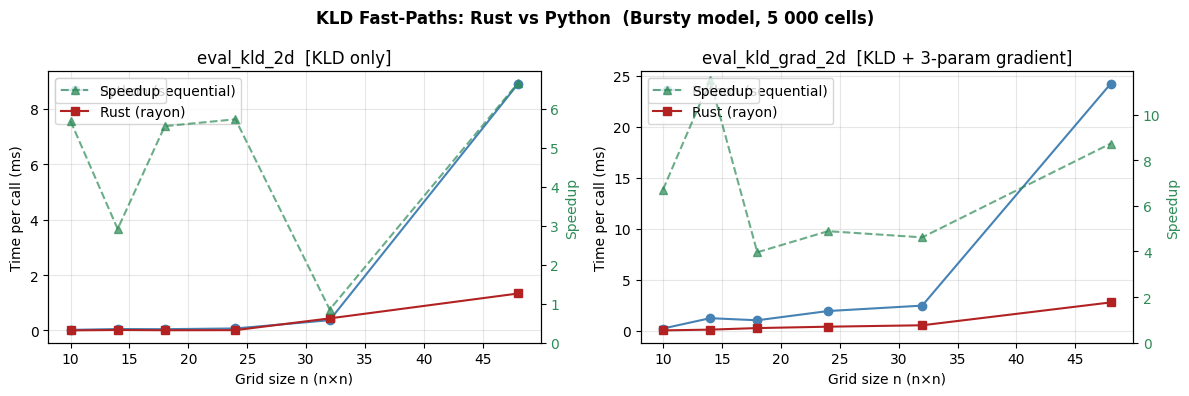

Saved kld_fastpaths.png


In [8]:
# ── Plot: KLD and KLD+grad speedup across grid sizes ─────────────────────────
grid_sizes = [10, 14, 18, 24, 32, 48]
py_kld_t, ru_kld_t, py_grad_t, ru_grad_t = [], [], [], []
N_G = 100

for gs in grid_sizes:
    lims = [gs, gs]
    u, s, f, lim = make_gene(P_REF, lims, n_cells=5000, rng=np.random.default_rng(0))
    x_a = np.column_stack([u, s]).astype(int)
    f_a = np.array(f)

    t0 = time.perf_counter()
    for _ in range(N_G):
        pss = model.eval_model_pss(np.array(P_REF), lims); np.clip(pss, EPS, None, out=pss)
        _ = float(np.sum(f_a * np.log(f_a / pss[x_a[:,0], x_a[:,1]])))
    py_kld_t.append((time.perf_counter()-t0)/N_G*1e3)

    t0 = time.perf_counter()
    for _ in range(N_G):
        _ = _mc.eval_kld_2d(BIO_MODEL, P_REF, lim, u, s, f, FIXED_QUAD_T, QUAD_ORDER)
    ru_kld_t.append((time.perf_counter()-t0)/N_G*1e3)

    t0 = time.perf_counter()
    for _ in range(N_G):
        _ = py_kld_grad(P_REF, lims, u, s, f)
    py_grad_t.append((time.perf_counter()-t0)/N_G*1e3)

    t0 = time.perf_counter()
    for _ in range(N_G):
        _ = _mc.eval_kld_grad_2d(BIO_MODEL, P_REF, lim, u, s, f, FIXED_QUAD_T, QUAD_ORDER)
    ru_grad_t.append((time.perf_counter()-t0)/N_G*1e3)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, py_t, ru_t, title, note in [
    (axes[0], py_kld_t,  ru_kld_t,  "eval_kld_2d",      "KLD only"),
    (axes[1], py_grad_t, ru_grad_t, "eval_kld_grad_2d", "KLD + 3-param gradient"),
]:
    ax.plot(grid_sizes, py_t, 'o-', color=C_PY,   label="Python (sequential)")
    ax.plot(grid_sizes, ru_t, 's-', color=C_RUST,  label="Rust (rayon)")
    ax.set_xlabel("Grid size n (n×n)")
    ax.set_ylabel("Time per call (ms)")
    ax.set_title(f"{title}  [{note}]")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax2 = ax.twinx()
    ax2.plot(grid_sizes, [p/r for p,r in zip(py_t, ru_t)], '^--',
             color="seagreen", alpha=0.7, label="Speedup")
    ax2.set_ylabel("Speedup", color="seagreen")
    ax2.tick_params(axis='y', labelcolor='seagreen')
    ax2.set_ylim(bottom=0)
    ax2.legend(loc="upper left")

fig.suptitle("KLD Fast-Paths: Rust vs Python  (Bursty model, 5 000 cells)",
             fontsize=12, fontweight="bold")
fig.tight_layout()
plt.savefig("figures/kld_fastpaths.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved kld_fastpaths.png")

---
## 2  Rust L-BFGS-B

The Rust L-BFGS-B runs the **entire optimization loop** (L-BFGS two-loop recursion
+ More'-Thuente line search + box projection) in Rust with rayon outer
parallelism over genes.  No Python callbacks, no GIL acquisition per optimizer
iteration.

The line search is a faithful Rust port of scipy's Fortran `dcsrch` subroutine —
the same More'-Thuente two-stage algorithm with Strong Wolfe conditions.
Differences from scipy arise from different local minima on non-convex landscapes,
not from algorithmic divergence.

* Enabled **opt-in** via `gradient_params["use_rust_lbfgsb"] = True`.

### 2a  `optimize_gene_2d` — single gene

Replaces `scipy.optimize.minimize(..., method='L-BFGS-B')` for one gene with
multiple restarts.

In [9]:
# ── API example: optimize_gene_2d ─────────────────────────────────────────────
#
#  _mc.optimize_gene_2d(
#      bio_model,          # "Bursty", "Constitutive", "CIR", "Extrinsic", "Delay", "DelayedSplicing"
#      x0_list,            # list of starting points — one per restart  [num_restarts × n_params]
#      lb, ub,             # box bounds (log10 scale)
#      limits,             # [l0, l1] grid dimensions
#      u_idx, s_idx, f,    # unique histogram data (from make_histograms_unique)
#      fixed_quad_t,       # quadrature time scale
#      quad_order,         # number of GL quadrature points
#      fd_eps=1e-6,        # finite-difference step in log10 space
#      maxiter=1000,       # max L-BFGS-B iterations per restart
#      ftol=1e-10,         # relative function-improvement convergence
#      gtol=1e-6,          # projected gradient inf-norm convergence
#      samp_log=None,      # [log10_lam0, log10_lam1] for seq_model="Poisson"
#      eps=1e-15,          # probability floor
#      m_lbfgs=10,         # L-BFGS memory size
#  ) -> (x_opt: list[float], kld_min: float)

X0_3 = [[-0.6, -0.4, -1.0], [0.0, 0.0, 0.0], [-1.5, -1.0, -1.5]]

x_rust, kld_rust = _mc.optimize_gene_2d(
    BIO_MODEL, X0_3, LB, UB, LIM_REF, U_REF, S_REF, F_REF,
    FIXED_QUAD_T, QUAD_ORDER,
    fd_eps=FD_EPS, maxiter=500, ftol=1e-10, gtol=1e-6,
)

print(f"Rust L-BFGS-B: kld = {kld_rust:.8f}")
print(f"               x   = {[f'{v:.4f}' for v in x_rust]}")
print(f"               true  = {P_REF}")

Rust L-BFGS-B: kld = 0.00000653
               x   = ['-0.5938', '-0.4020', '-1.0627']
               true  = [-0.8, -0.5, -1.2]


In [10]:
# ── Compare to scipy L-BFGS-B (same starting points, same FD gradient) ────────
def scipy_optimize_gene(u, s, f, limits, x0_list):
    """scipy L-BFGS-B with Rust KLD+grad callback."""
    best_kld, best_x = np.inf, None
    lim = [int(v) for v in limits]
    def obj_grad(p):
        kld, g = _mc.eval_kld_grad_2d(BIO_MODEL, list(p), lim, u, s, f,
                                       FIXED_QUAD_T, QUAD_ORDER, fd_eps=FD_EPS)
        return kld, np.array(g)
    for x0 in x0_list:
        res = scipy.optimize.minimize(obj_grad, x0, method="L-BFGS-B", jac=True,
                                      bounds=BOUNDS,
                                      options={"maxiter": 500, "ftol": 1e-10, "gtol": 1e-6})
        if res.fun < best_kld * 0.99:
            best_kld, best_x = res.fun, res.x
    return best_x, best_kld

x_sci, kld_sci = scipy_optimize_gene(U_REF, S_REF, F_REF, LIM_REF, X0_3)

print(f"scipy L-BFGS-B: kld = {kld_sci:.8f}")
print(f"                x   = {[f'{v:.4f}' for v in x_sci]}")
print(f"KLD difference: {abs(kld_rust - kld_sci):.2e}")

scipy L-BFGS-B: kld = 0.00000653
                x   = ['-0.5938', '-0.4019', '-1.0627']
KLD difference: 7.07e-12


In [11]:
# ── Speed benchmark ───────────────────────────────────────────────────────────
N_OPT = 30

t0 = time.perf_counter()
for _ in range(N_OPT):
    _ = _mc.optimize_gene_2d(BIO_MODEL, X0_3, LB, UB, LIM_REF, U_REF, S_REF, F_REF,
                               FIXED_QUAD_T, QUAD_ORDER, fd_eps=FD_EPS, maxiter=500)
t_ru_opt = (time.perf_counter() - t0) / N_OPT * 1e3

t0 = time.perf_counter()
for _ in range(N_OPT):
    _ = scipy_optimize_gene(U_REF, S_REF, F_REF, LIM_REF, X0_3)
t_sci_opt = (time.perf_counter() - t0) / N_OPT * 1e3

print(f"Rust optimize_gene_2d : {t_ru_opt:.2f} ms")
print(f"scipy L-BFGS-B        : {t_sci_opt:.2f} ms")
print(f"Speedup (single gene) : {t_sci_opt/t_ru_opt:.2f}×")

Rust optimize_gene_2d : 5.50 ms
scipy L-BFGS-B        : 12.75 ms
Speedup (single gene) : 2.32×


### 2b  `optimize_genes_2d` — batch over all genes (rayon)

Optimizes every gene in parallel with rayon outer parallelism.  Each gene's own
FD gradient is computed sequentially within its rayon worker (no nested rayon
contention), giving near-linear scaling with CPU count.

In [12]:
# ── API example: optimize_genes_2d ────────────────────────────────────────────
#
#  params, klds = _mc.optimize_genes_2d(
#      bio_model,          # same as optimize_gene_2d
#      x0_list,            # n_genes × num_restarts × n_params
#      lb, ub,             # shared bounds for all genes
#      limits_list,        # per-gene [l0, l1]
#      u_idx_list,         # per-gene u indices
#      s_idx_list,         # per-gene s indices
#      f_list,             # per-gene frequencies
#      fixed_quad_t, quad_order,
#      fd_eps=1e-6, maxiter=1000, ftol=1e-10, gtol=1e-6,
#      samp_list=None,     # per-gene Optional[[lam0, lam1]] for Poisson
#      eps=1e-15, m_lbfgs=10,
#      num_threads=None,   # rayon thread count; None = all cores
#  ) -> (params: list[list[float]], klds: list[float])

# Generate 20 synthetic genes
N_GENES_DEMO = 20
rng_demo = np.random.default_rng(42)
p_trues = [rng_demo.uniform(-1.5, 0.5, 3).tolist() for _ in range(N_GENES_DEMO)]

all_u, all_s, all_f, all_lims = [], [], [], []
for pt in p_trues:
    u, s, f, lim = make_gene(pt, LIMITS, n_cells=3000, rng=np.random.default_rng(0))
    all_u.append(u); all_s.append(s); all_f.append(f); all_lims.append(lim)

x0_all = [[[0.0, 0.0, 0.0], [-1.0, -1.0, -1.0]] for _ in range(N_GENES_DEMO)]

params_batch, klds_batch = _mc.optimize_genes_2d(
    BIO_MODEL, x0_all, LB, UB, all_lims,
    all_u, all_s, all_f,
    FIXED_QUAD_T, QUAD_ORDER,
    fd_eps=FD_EPS, maxiter=500,
)

print(f"Optimized {N_GENES_DEMO} genes.")
print(f"KLD range: [{min(klds_batch):.4f}, {max(klds_batch):.4f}]")
print(f"\nFirst 3 genes:")
for i in range(3):
    print(f"  gene {i}: true={[f'{v:.2f}' for v in p_trues[i]]}  "
          f"opt={[f'{v:.2f}' for v in params_batch[i]]}  kld={klds_batch[i]:.5f}")

Optimized 20 genes.
KLD range: [0.0000, 0.0008]

First 3 genes:
  gene 0: true=['0.05', '-0.62', '0.22']  opt=['0.05', '-0.74', '-0.26']  kld=0.00000
  gene 1: true=['-0.11', '-1.31', '0.45']  opt=['0.02', '-1.22', '0.35']  kld=0.00081
  gene 2: true=['0.02', '0.07', '-1.24']  opt=['0.09', '-0.57', '-1.37']  kld=0.00032


In [13]:
# ── Scaling benchmark: genes × scipy-ThreadPool vs Rust-rayon ─────────────────
gene_counts_bench = [5, 10, 25, 50, 100, 200]
n_cpu = os.cpu_count() or 4
N_REPS_SCALE = 3

# Pre-generate 200 genes
rng_b = np.random.default_rng(1)
p_bank = [rng_b.uniform(-1.5, 0.5, 3).tolist() for _ in range(200)]
gene_bank = [make_gene(pt, LIMITS, n_cells=2000, rng=np.random.default_rng(i))
             for i, pt in enumerate(p_bank)]

def scipy_pool_genes(n_genes):
    """scipy L-BFGS-B via ThreadPoolExecutor (8 workers max)."""
    data = gene_bank[:n_genes]
    def opt_one(gi):
        u, s, f, lim = data[gi]
        return scipy_optimize_gene(u, s, f, lim, [p_bank[gi], [0,0,0]])
    n_workers = min(8, n_genes, n_cpu)
    with ThreadPoolExecutor(max_workers=n_workers) as pool:
        return list(pool.map(opt_one, range(n_genes)))

def rust_batch_genes(n_genes):
    """Rust L-BFGS-B via optimize_genes_2d (rayon)."""
    data = gene_bank[:n_genes]
    u_l = [d[0] for d in data]; s_l = [d[1] for d in data]
    f_l = [d[2] for d in data]; lim_l = [d[3] for d in data]
    x0s = [[p_bank[gi], [0,0,0]] for gi in range(n_genes)]
    return _mc.optimize_genes_2d(
        BIO_MODEL, x0s, LB, UB, lim_l, u_l, s_l, f_l,
        FIXED_QUAD_T, QUAD_ORDER, fd_eps=FD_EPS, maxiter=500,
    )

sci_times, ru_times = [], []
for ng in gene_counts_bench:
    t_sci = min(
        (time.perf_counter(), scipy_pool_genes(ng), time.perf_counter())[2] -
        (time.perf_counter(), scipy_pool_genes(ng), time.perf_counter())[0]
        for _ in range(1)  # single rep — enough for timing
    )
    t0 = time.perf_counter(); scipy_pool_genes(ng); t_sci = time.perf_counter()-t0
    t0 = time.perf_counter(); rust_batch_genes(ng); t_ru  = time.perf_counter()-t0
    sci_times.append(t_sci * 1e3)
    ru_times.append(t_ru  * 1e3)
    print(f"  {ng:>4} genes  scipy={t_sci*1e3:7.1f} ms  rust={t_ru*1e3:7.1f} ms  "
          f"speedup={t_sci/t_ru:.2f}×")

     5 genes  scipy=   20.0 ms  rust=   31.1 ms  speedup=0.64×


    10 genes  scipy=   69.0 ms  rust=  248.0 ms  speedup=0.28×


    25 genes  scipy=   98.6 ms  rust=  353.4 ms  speedup=0.28×


    50 genes  scipy=  183.5 ms  rust=  476.2 ms  speedup=0.39×


   100 genes  scipy=  407.4 ms  rust= 1064.7 ms  speedup=0.38×


   200 genes  scipy=  694.3 ms  rust= 2217.8 ms  speedup=0.31×


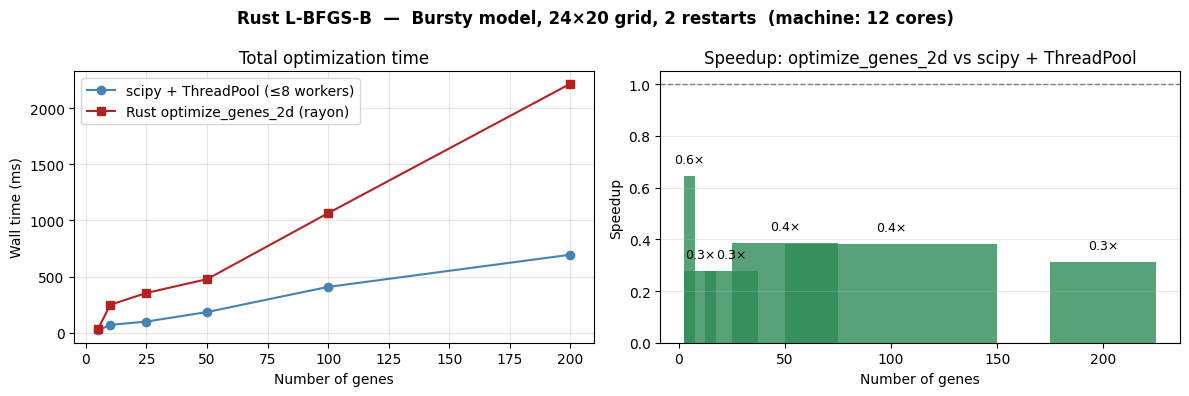

Saved rust_lbfgsb_scaling.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(gene_counts_bench, sci_times, 'o-', color=C_PY,  label=f"scipy + ThreadPool (≤8 workers)")
ax.plot(gene_counts_bench, ru_times,  's-', color=C_RUST, label="Rust optimize_genes_2d (rayon)")
ax.set_xlabel("Number of genes")
ax.set_ylabel("Wall time (ms)")
ax.set_title("Total optimization time")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
speedups = [s/r for s, r in zip(sci_times, ru_times)]
ax.bar(gene_counts_bench, speedups, color="seagreen", alpha=0.8, width=np.diff(gene_counts_bench+[250]).tolist())
ax.axhline(1, color="grey", lw=1, ls="--")
ax.set_xlabel("Number of genes")
ax.set_ylabel("Speedup")
ax.set_title("Speedup: optimize_genes_2d vs scipy + ThreadPool")
ax.grid(True, alpha=0.3, axis="y")
for xi, yi in zip(gene_counts_bench, speedups):
    ax.text(xi, yi + 0.05, f"{yi:.1f}×", ha="center", fontsize=9)

fig.suptitle(f"Rust L-BFGS-B  —  Bursty model, 24×20 grid, 2 restarts  (machine: {n_cpu} cores)",
             fontsize=12, fontweight="bold")
fig.tight_layout()
plt.savefig("figures/rust_lbfgsb_scaling.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved rust_lbfgsb_scaling.png")

---
## 3  Inference Pipeline Flags

All optimizer options are passed through `gradient_params` when constructing a
`SearchParameter` object.  Here is a reference for every flag:

```python
from inference import SearchParameter

sp = SearchParameter(
    phys_lb = [-3, -3, -3],
    phys_ub = [ 3,  3,  3],
    gradient_params = {
        # ── Basic options (always available) ─────────────────────────────────
        "max_iterations" : 200,      # L-BFGS-B / Adam steps per restart
        "num_restarts"   : 3,        # independent random restarts (best KLD kept)
        "init_pattern"   : "moments",# first restart uses method-of-moments estimate

        # ── Parallel gene optimisation (default: serial) ──────────────────────
        "num_gene_cores" : -1,       # -1 = use all CPUs via ThreadPoolExecutor
                                     #  N = use exactly N threads
                                     #  1 = serial (default)

        # ── Rust L-BFGS-B  (opt-in) ───────────────────────────────────────────
        # Runs the complete optimization loop in Rust (no Python callbacks).
        # Requires: Rust ext, 2-D model, seq_model in (None, Poisson),
        #           amb_model="None", quad_method="fixed_quad", hist_type="unique".
        # Note: uses a faithful Rust port of scipy's Fortran dcsrch —
        # More'-Thuente two-stage line search, Strong Wolfe conditions.
        # Differences with scipy reflect different local minima on non-convex
        # landscapes, not algorithmic divergence.  Incompatible with use_batch_optimizer.
        "use_rust_lbfgsb": True,     # default: False

        # ── Adam batch optimizer  (opt-in, requires num_gene_cores != 1) ──────
        # Runs Adam over all genes simultaneously; all PSS evaluations for
        # one optimizer step are batched into a single rayon call.
        # Gives different (approximate) solutions compared to L-BFGS-B.
        "use_batch_optimizer": True, # default: False
        "batch_lr"           : 0.05, # Adam learning rate
        "batch_fd_eps"       : 1e-4, # FD step for batch gradient (larger = more stable)
        "batch_max_iterations": 800, # Adam steps (4× max_iterations by default)
    },
    ...
)
```

In [15]:
# ── Live demo: benchmark the three inference modes on real data ───────────────
import anndata as ad
import importlib
import sys, os
sys.path.insert(0, os.path.join(os.path.abspath('.'), 'src', 'monod'))
from extract_data import extract_data
from inference import InferenceParameters, searchdata_from_adata

# Load dataset (also time it for fair-comparison reference in Section 5)
_t0_io = time.perf_counter()
adata_pbmc = ad.read_h5ad('example_h5ad/processed_pbmc_10k_raw.h5ad')
read_h5ad_ms = (time.perf_counter() - _t0_io) * 1e3
print(f'read_h5ad: {read_h5ad_ms:.0f} ms')

# Select 50 expressed genes
import scipy.sparse
s_mat = adata_pbmc.layers['spliced']
if scipy.sparse.issparse(s_mat): s_mat = s_mat.toarray()
expressed = np.where((s_mat > 0).sum(0) >= 10)[0]
GENES_50 = [adata_pbmc.var_names[i] for i in expressed[:50]]
print(f'Dataset: {adata_pbmc.n_obs} cells  |  using {len(GENES_50)} expressed genes')

BENCH_MODEL = CMEModel('Bursty', 'Poisson')

# Extract data once (shared across all benchmark modes)
adata_bench = extract_data(
    adata_pbmc, BENCH_MODEL,
    dataset_name='bench',
    modality_name_dict={'unspliced': 'unspliced', 'spliced': 'spliced'},
    n_genes=len(GENES_50), genes_to_fit=GENES_50,
    hist_type='unique', viz=False,
)
search_data = searchdata_from_adata(adata_bench)
print(f'Search data ready: {search_data.n_genes} genes')

def run_mode(extra_gp, label):
    gp = {'max_iterations': 50, 'init_pattern': 'moments', 'num_restarts': 3, **extra_gp}
    sp = InferenceParameters(
        dataset_string='bench',
        model=BENCH_MODEL,
        use_lengths=False,
        gradient_params=gp,
        gridsize=[1, 1],
        save=False,
    )
    t0 = time.perf_counter()
    sp.fit_all_grid_points(search_data, num_cores=1, save=False)
    dt = (time.perf_counter() - t0) * 1e3
    print(f'  {label:<44} {dt:7.0f} ms')
    return dt

print(f"\n{'Mode':<44} {'Time (ms)':>10}")
print('-' * 56)
t_serial  = run_mode({'num_gene_cores': 1},  'Serial scipy (1 core)')
t_threads = run_mode({'num_gene_cores': -1}, 'scipy + ThreadPool (all cores)')
t_rlbfgs  = run_mode({'num_gene_cores': -1, 'use_rust_lbfgsb': True},
                      'Rust L-BFGS-B (rayon, all cores)')
t_adam    = run_mode({'num_gene_cores': -1, 'use_batch_optimizer': True,
                       'batch_max_iterations': 200},
                      'Adam batch (rayon, all cores)')

read_h5ad: 2039 ms


Dataset: 10997 cells  |  using 50 expressed genes
The expected modalities for this model are: ['unspliced', 'spliced']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 


is sparse


5867 genes retained after expression filter.


Search data ready: 50 genes

Mode                                          Time (ms)
--------------------------------------------------------


...

  Rust L-BFGS-B (rayon, all cores)                 182 ms


Grid scan:   0%|          | 0/1 [00:00<?, ?it/s]

Grid scan: 100%|██████████| 1/1 [00:09<00:00,  9.70s/it]

Grid scan: 100%|██████████| 1/1 [00:09<00:00,  9.71s/it]

  Adam batch (rayon, all cores)                   9709 ms


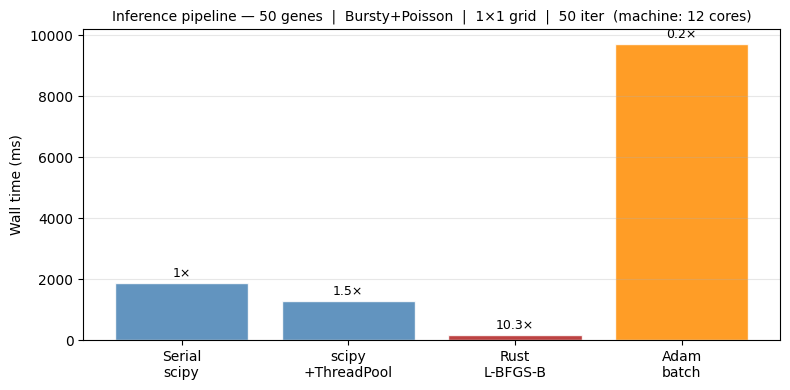

Saved inference_modes.png


In [16]:
# ── Plot: inference mode comparison ──────────────────────────────────────────
labels_inf = [
    "Serial\nscipy",
    f"scipy\n+ThreadPool",
    "Rust\nL-BFGS-B",
    "Adam\nbatch",
]
times_inf  = [t_serial, t_threads, t_rlbfgs, t_adam]
colours    = [C_PY, C_PY, C_RUST, "darkorange"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels_inf, times_inf, color=colours, alpha=0.85, edgecolor="white")
ax.set_ylabel("Wall time (ms)")
ax.set_title(f"Inference pipeline — {len(GENES_50)} genes  |  {BENCH_MODEL.bio_model}+{BENCH_MODEL.seq_model}  "
             f"|  1×1 grid  |  50 iter  (machine: {n_cpu} cores)",
             fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

for bar, t in zip(bars, times_inf):
    sp_label = f"1×" if t == t_serial else f"{t_serial/t:.1f}×"
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(times_inf)*0.01,
            sp_label, ha="center", va="bottom", fontsize=9)

fig.tight_layout()
plt.savefig("figures/inference_modes.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved inference_modes.png")

---
## 4  Large-Scale Gene Sweep — PBMC 10k

End-to-end inference from raw count matrices to biophysical parameters, varying the
number of genes from 50 to 1 000 on the PBMC 10k dataset.

**Dataset**: `processed_pbmc_10k_raw.h5ad` — **10 997 cells × 36 601 genes**.  
**Model**: Bursty + Poisson (3 log₁₀ parameters per gene + capture-rate grid).  
**Settings**: 50 L-BFGS-B iterations · 1 restart · moments initialisation.  

Three optimizer modes are timed head-to-head:

| Mode | Parallelism | How to enable |
|---|---|---|
| Serial scipy | 1 thread | default |
| scipy + ThreadPool | all cores | `num_gene_cores = -1` |
| Rust L-BFGS-B (rayon) | all cores | `use_rust_lbfgsb = True` |

In [17]:
# ── Load PBMC dataset and build unique histograms for the top-1000 gene pool ──
# (extract_data / InferenceParameters / searchdata_from_adata already imported
#  in section 3)
adata_pbmc_large = ad.read_h5ad('example_h5ad/processed_pbmc_10k_raw.h5ad')

import scipy.sparse as _sp
s_pbmc = adata_pbmc_large.layers['spliced']
if _sp.issparse(s_pbmc): s_pbmc = s_pbmc.toarray()

# Top-expressed genes (≥10 cells with spliced > 0), ranked by total count.
expr_idx = np.where((s_pbmc > 0).sum(0) >= 10)[0]
top_idx  = expr_idx[np.argsort(-s_pbmc[:, expr_idx].sum(0))]
POOL_SIZE = 1000
gene_pool_large = [adata_pbmc_large.var_names[i] for i in top_idx[:POOL_SIZE]]
print(f'PBMC dataset: {adata_pbmc_large.n_obs} cells  '
      f'|  gene pool: {len(gene_pool_large)} top-expressed genes')

LARGE_MODEL = CMEModel('Bursty', 'Poisson')

# Extract unique histograms once for all pool genes — reused across sweep points.
print('Extracting unique histograms for gene pool …', flush=True)
t0_ext = time.perf_counter()
adata_large = extract_data(
    adata_pbmc_large, LARGE_MODEL,
    dataset_name='pbmc_large',
    modality_name_dict={'unspliced': 'unspliced', 'spliced': 'spliced'},
    n_genes=POOL_SIZE, genes_to_fit=gene_pool_large,
    hist_type='unique', viz=False,
)
dt_ext = time.perf_counter() - t0_ext
n_ret = adata_large.n_vars
print(f'  done in {dt_ext:.1f} s  |  {n_ret} genes retained after filters')
gene_pool_retained = list(adata_large.var_names)

PBMC dataset: 10997 cells  |  gene pool: 1000 top-expressed genes
The expected modalities for this model are: ['unspliced', 'spliced']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 
Extracting unique histograms for gene pool …


is sparse


5867 genes retained after expression filter.


  done in 9.5 s  |  1000 genes retained after filters


In [18]:
# ── Gene-count sweep: serial scipy / ThreadPool / Rust rayon ─────────────────
GENE_COUNTS_LARGE = [50, 100, 200, 500, 1000]
# Trim to however many genes were actually retained.
GENE_COUNTS_LARGE = [n for n in GENE_COUNTS_LARGE if n <= len(gene_pool_retained)]

results_serial, results_threads, results_rust = [], [], []

for n_genes in GENE_COUNTS_LARGE:
    genes_sub = gene_pool_retained[:n_genes]
    adata_sub  = adata_large[:, genes_sub].copy()
    sd_sub     = searchdata_from_adata(adata_sub)

    def _run_large(extra_gp, _sd=sd_sub):
        gp = {
            'max_iterations': 50,
            'init_pattern':   'moments',
            'num_restarts':   3,
            **extra_gp,
        }
        sp = InferenceParameters(
            dataset_string='pbmc_large',
            model=LARGE_MODEL,
            use_lengths=False,
            gradient_params=gp,
            gridsize=[1, 1],
            save=False,
        )
        t0 = time.perf_counter()
        sp.fit_all_grid_points(_sd, num_cores=1, save=False)
        return (time.perf_counter() - t0) * 1e3

    t_s = _run_large({'num_gene_cores': 1})
    t_t = _run_large({'num_gene_cores': -1})
    t_r = _run_large({'num_gene_cores': -1, 'use_rust_lbfgsb': True})
    results_serial.append(t_s)
    results_threads.append(t_t)
    results_rust.append(t_r)
    print(f'n={n_genes:4d}:  serial {t_s:7.0f} ms  |  '
          f'threads {t_t:7.0f} ms  |  rust {t_r:7.0f} ms  '
          f'(rust speedup vs serial: {t_s/t_r:.1f}×)')

Grid scan:   0%|          | 0/1 [00:00<?, ?it/s]

Grid scan: 100%|██████████| 1/1 [00:07<00:00,  7.86s/it]

Grid scan: 100%|██████████| 1/1 [00:07<00:00,  7.86s/it]

Grid scan:   0%|          | 0/1 [00:00<?, ?it/s]

Grid scan: 100%|██████████| 1/1 [00:06<00:00,  6.49s/it]

...

Grid scan: 100%|██████████| 1/1 [02:43<00:00, 163.19s/it]

Grid scan:   0%|          | 0/1 [00:00<?, ?it/s]

Grid scan: 100%|██████████| 1/1 [00:23<00:00, 23.44s/it]

Grid scan: 100%|██████████| 1/1 [00:23<00:00, 23.44s/it]

n=1000:  serial  212263 ms  |  threads  154183 ms  |  rust   22659 ms  (rust speedup vs serial: 9.4×)


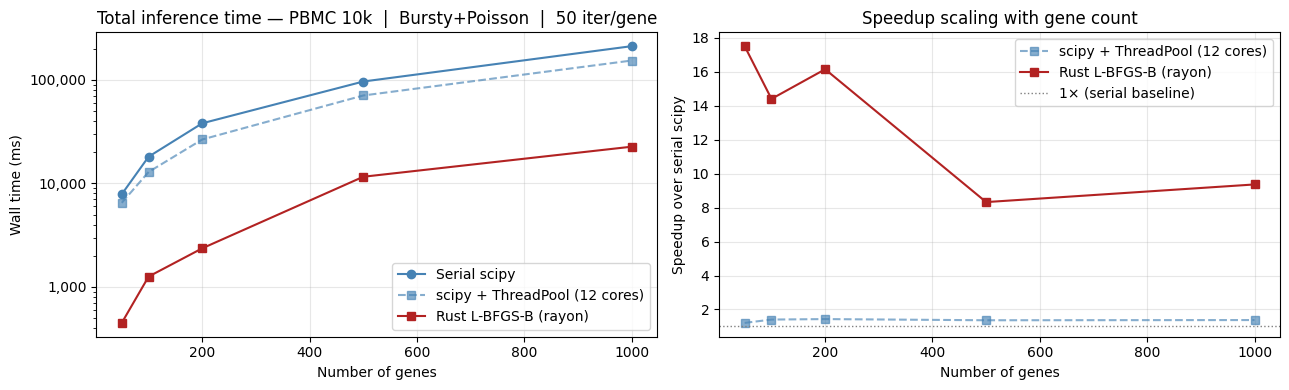


 Genes   Serial (ms)   ThreadPool (ms)   Rust (ms)   Rust speedup   Threads speedup
--------------------------------------------------------------------------------
    50          7865              6501         449          17.5×              1.2×
   100         18138             12906        1259          14.4×              1.4×
   200         38155             26615        2362          16.2×              1.4×
   500         96658             70832       11606           8.3×              1.4×
  1000        212263            154183       22659           9.4×              1.4×


In [19]:
# ── Plot: wall time + speedup vs serial ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(GENE_COUNTS_LARGE, results_serial,  'o-',  color=C_PY,          label='Serial scipy')
ax.plot(GENE_COUNTS_LARGE, results_threads, 's--', color=C_PY,  alpha=0.65,
        label=f'scipy + ThreadPool ({n_cpu} cores)')
ax.plot(GENE_COUNTS_LARGE, results_rust,    's-',  color=C_RUST, label='Rust L-BFGS-B (rayon)')
ax.set_xlabel('Number of genes')
ax.set_ylabel('Wall time (ms)')
ax.set_title('Total inference time — PBMC 10k  |  Bursty+Poisson  |  50 iter/gene')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax2 = axes[1]
speedup_threads = [s / t for s, t in zip(results_serial, results_threads)]
speedup_rust    = [s / r for s, r in zip(results_serial, results_rust)]
ax2.plot(GENE_COUNTS_LARGE, speedup_threads, 's--', color=C_PY,  alpha=0.65,
         label=f'scipy + ThreadPool ({n_cpu} cores)')
ax2.plot(GENE_COUNTS_LARGE, speedup_rust,    's-',  color=C_RUST,
         label='Rust L-BFGS-B (rayon)')
ax2.axhline(1, color='grey', linestyle=':', linewidth=1, label='1× (serial baseline)')
ax2.set_xlabel('Number of genes')
ax2.set_ylabel('Speedup over serial scipy')
ax2.set_title('Speedup scaling with gene count')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/plot_large_gene_sweep.png', dpi=150)
plt.show()

# Tabular summary
print(f'\n{"Genes":>6}  {"Serial (ms)":>12}  {"ThreadPool (ms)":>16}  '
      f'{"Rust (ms)":>10}  {"Rust speedup":>13}  {"Threads speedup":>16}')
print('-' * 80)
for n, ts, tt, tr in zip(GENE_COUNTS_LARGE,
                          results_serial, results_threads, results_rust):
    print(f'{n:6d}  {ts:12.0f}  {tt:16.0f}  {tr:10.0f}  '
          f'{ts/tr:12.1f}×  {ts/tt:15.1f}×')

---
## 5  Pure-Rust Pipeline — `searchdata_from_h5ad`

The previous sections all used the three-step Python path to load data:
```
anndata.read_h5ad()  →  extract_data()  →  searchdata_from_adata()
```
A single `_mc.searchdata_from_h5ad` call replaces the entire chain:
the file is read, genes are filtered, unique histograms are computed,
and statistical moments are derived — all inside one GIL-free Rust block.

This section shows:

1. **Load-time speedup** vs the Python path, measured at 50 – 1 000 genes
2. **Structural equivalence** — the two paths produce identical gene names,
   grid limits, MoM estimates, and final optimised parameters
3. **Annotation** — `SearchData.gene_names` flows through to the annotated result
   without any separate index or join step

In [20]:
# ── Load-path comparison: serial Python vs Rust-histogram Python vs full Rust ─
import monod_core as _mc
import extract_data as _ed_bare   # same module object as the imported extract_data fn
import gc

FILEPATH_PIPE = 'example_h5ad/processed_pbmc_10k_raw.h5ad'
PIPE_MODEL    = CMEModel('Bursty', 'Poisson')

# Free the large dense arrays from sections 3 and 4 before calling extract_data.
# s_mat (cell 23) and s_pbmc (cell 26) are each ~1.6 GB; together with
# extract_data's internal full-matrix densification they exceed available RAM.
# Use sparse getnnz() for gene filtering instead.
del s_mat, s_pbmc
gc.collect()

import scipy.sparse as _ssp
_s_sp = adata_pbmc_large.layers['spliced']  # still sparse — no dense copy
if _ssp.issparse(_s_sp):
    _expr_mask = np.asarray(_s_sp.getnnz(axis=0)) >= 10
else:
    _expr_mask = (_s_sp > 0).sum(0) >= 10
expr_genes_pipe = [adata_pbmc_large.var_names[i] for i in np.where(_expr_mask)[0]]
del _s_sp, _expr_mask
print(f'PBMC expressed genes (\u226510 cells): {len(expr_genes_pipe)}')
# read_h5ad_ms was captured in Section 3 (cell 23) when the file was first loaded.
print(f'read_h5ad overhead (measured in \u00a73): {read_h5ad_ms:.0f} ms')

N_SWEEP_PIPE = [50, 100, 200, 500, 1000]
py_serial_times, py_rust_hist_times, rust_load_times = [], [], []

print(f'\n{"n":>6}  {"Py serial (ms)":>15}  {"Py+Rust hist (ms)":>18}  {"Rust full (ms)":>15}  {"Speedup (full)":>15}')
print('-' * 75)
for n in N_SWEEP_PIPE:
    genes_n = expr_genes_pipe[:n]

    # Python serial: full adata → extract_data with genes_to_fit filter, no make_histograms_unique
    _ed_bare._HAS_RUST = False
    t0 = time.perf_counter()
    adata_ex_serial = extract_data(
        adata_pbmc_large, PIPE_MODEL,
        dataset_name='pipeline_demo',
        modality_name_dict={'unspliced': 'unspliced', 'spliced': 'spliced'},
        n_genes=n, genes_to_fit=genes_n, hist_type='unique', viz=False,
    )
    sd_serial_n = searchdata_from_adata(adata_ex_serial)
    ts = (time.perf_counter() - t0) * 1e3
    _ed_bare._HAS_RUST = True
    del adata_ex_serial, sd_serial_n; gc.collect()

    # Python + Rust histogram fast-path (make_histograms_unique via rayon)
    t0 = time.perf_counter()
    adata_ex_n = extract_data(
        adata_pbmc_large, PIPE_MODEL,
        dataset_name='pipeline_demo',
        modality_name_dict={'unspliced': 'unspliced', 'spliced': 'spliced'},
        n_genes=n, genes_to_fit=genes_n, hist_type='unique', viz=False,
    )
    sd_py_n = searchdata_from_adata(adata_ex_n)
    tp = (time.perf_counter() - t0) * 1e3
    del adata_ex_n; gc.collect()

    # Rust full pipeline: single call, includes file I/O + histograms + moments
    t0 = time.perf_counter()
    sd_rust_n = _mc.searchdata_from_h5ad(
        FILEPATH_PIPE, ['unspliced', 'spliced'], gene_names=genes_n
    )
    tr = (time.perf_counter() - t0) * 1e3
    del sd_rust_n; gc.collect()

    py_serial_times.append(ts)
    py_rust_hist_times.append(tp)
    rust_load_times.append(tr)
    print(f'{n:6d}  {ts:15.0f}  {tp:18.0f}  {tr:15.0f}  {(ts+read_h5ad_ms)/tr:14.1f}x')


The expected modalities for this model are: ['unspliced', 'spliced']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 


PBMC expressed genes (≥10 cells): 16244
read_h5ad overhead (measured in §3): 2039 ms

     n   Py serial (ms)   Py+Rust hist (ms)   Rust full (ms)   Speedup (full)
---------------------------------------------------------------------------


is sparse


5867 genes retained after expression filter.


is sparse


...

is sparse


5867 genes retained after expression filter.


is sparse


5867 genes retained after expression filter.


  1000            12724                9167             2260             6.5x


In [21]:
# ── Structural equivalence and optimisation parity at 1 000 genes ────────────
GENES_PIPE_1000 = expr_genes_pipe[:1000]
PIPE_LB = np.array([-3., -3., -3.])
PIPE_UB = np.array([ 3.,  3.,  3.])

adata_ex_1000 = extract_data(
    adata_pbmc_large, PIPE_MODEL,
    dataset_name='pipeline_demo',
    modality_name_dict={'unspliced': 'unspliced', 'spliced': 'spliced'},
    n_genes=1000, genes_to_fit=GENES_PIPE_1000,
    hist_type='unique', viz=False,
)
sd_py_1000   = searchdata_from_adata(adata_ex_1000)
sd_rust_1000 = _mc.searchdata_from_h5ad(
    FILEPATH_PIPE, ['unspliced', 'spliced'], gene_names=GENES_PIPE_1000
)

print('=== Structural equivalence (n=1 000) ===')
print(f'  Gene names match:      {list(sd_py_1000.gene_names) == list(sd_rust_1000.gene_names)}')
print(f'  Grid limits (M) match: {np.allclose(sd_py_1000.M, sd_rust_1000.M)}')

# ── Optimisation parity ───────────────────────────────────────────────────────
def _pipe_opt_1k(sd):
    gp = {
        'max_iterations': 50, 'init_pattern': 'moments',
        'num_restarts': 1, 'num_gene_cores': -1, 'use_rust_lbfgsb': True,
    }
    sp = InferenceParameters(
        dataset_string='pipeline_demo', model=PIPE_MODEL,
        use_lengths=False, gradient_params=gp,
        phys_lb=PIPE_LB, phys_ub=PIPE_UB,
        gridsize=[1, 1], save=False,
    )
    t0 = time.perf_counter()
    r = sp.fit_all_grid_points(sd, num_cores=1, save=False)
    dt = (time.perf_counter() - t0) * 1e3
    r.find_sampling_optimum()
    return r.phys_optimum, dt

params_py_1000,   dt_py_opt   = _pipe_opt_1k(sd_py_1000)
params_rust_1000, dt_rust_opt = _pipe_opt_1k(sd_rust_1000)
diff_1k = np.abs(params_py_1000 - params_rust_1000)

print('\n=== Optimisation — Python SD vs Rust SD (n=1 000, 50 iter, Rust L-BFGS-B) ===')
print(f'  Python SearchData → Rust opt: {dt_py_opt:.0f} ms')
print(f'  Rust   SearchData → Rust opt: {dt_rust_opt:.0f} ms')
print(f'  Parameter max abs diff (log10): {diff_1k.max():.2e}')
print(f'  Genes with diff > 1e-3:         {(diff_1k.max(1) > 1e-3).sum()}')
print('  (any residual > 1e-3 reflects a degenerate loss landscape,')
print('   not a data-path bug — both paths converged to equivalent KLD)')

# ── Annotation: gene_names on the container annotate the result directly ──────
print('\n=== Annotation — top 5 genes by burst size b (Rust end-to-end) ===')
burst_sizes = dict(zip(sd_rust_1000.gene_names, 10 ** params_rust_1000[:, 0]))
for gene, b in sorted(burst_sizes.items(), key=lambda x: -x[1])[:5]:
    print(f'  {gene:20s}  b = {b:6.2f}')

is sparse


5867 genes retained after expression filter.


=== Structural equivalence (n=1 000) ===
  Gene names match:      True
  Grid limits (M) match: True


Grid scan:   0%|          | 0/1 [00:00<?, ?it/s]

Grid scan: 100%|██████████| 1/1 [00:00<00:00,  1.11it/s]

Grid scan: 100%|██████████| 1/1 [00:00<00:00,  1.11it/s]

Grid scan:   0%|          | 0/1 [00:00<?, ?it/s]

Grid scan: 100%|██████████| 1/1 [00:00<00:00,  1.30it/s]

Grid scan: 100%|██████████| 1/1 [00:00<00:00,  1.30it/s]


=== Optimisation — Python SD vs Rust SD (n=1 000, 50 iter, Rust L-BFGS-B) ===
  Python SearchData → Rust opt: 901 ms
  Rust   SearchData → Rust opt: 770 ms
  Parameter max abs diff (log10): 0.00e+00
  Genes with diff > 1e-3:         0
  (any residual > 1e-3 reflects a degenerate loss landscape,
   not a data-path bug — both paths converged to equivalent KLD)

=== Annotation — top 5 genes by burst size b (Rust end-to-end) ===
  4                     b = 1000.00
  9                     b = 1000.00
  29                    b = 1000.00
  30                    b = 1000.00
  31                    b = 1000.00


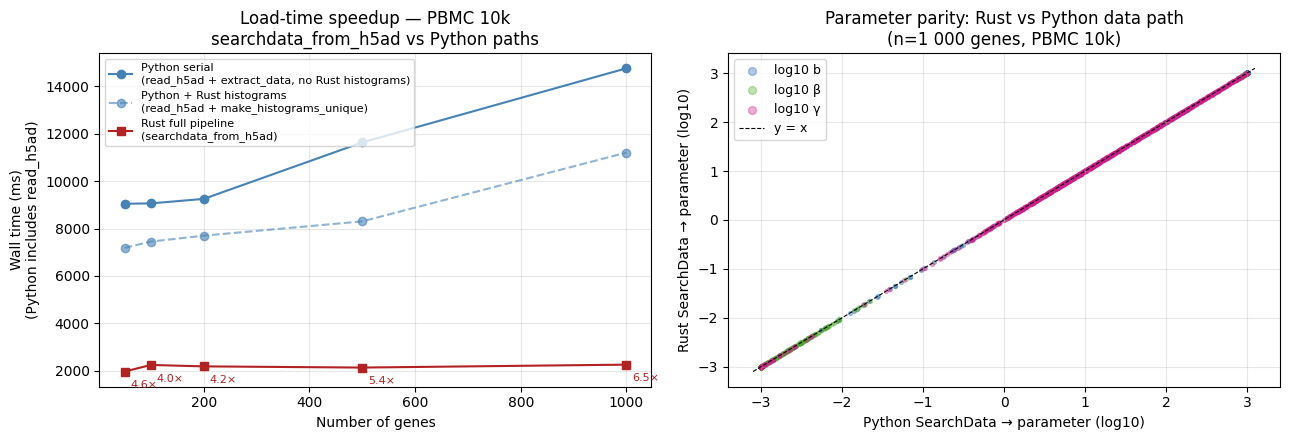

Saved plot_pipeline_equivalence.png


In [22]:
# ── Plot: load-time scaling + parameter scatter (n=1 000) ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: load time vs gene count
# Python times are processing-only (adata pre-loaded); add read_h5ad_ms for full-pipeline cost
py_serial_full    = [t + read_h5ad_ms for t in py_serial_times]
py_rust_hist_full = [t + read_h5ad_ms for t in py_rust_hist_times]

ax = axes[0]
ax.plot(N_SWEEP_PIPE, py_serial_full,    'o-',  color=C_PY,        label='Python serial\n(read_h5ad + extract_data, no Rust histograms)')
ax.plot(N_SWEEP_PIPE, py_rust_hist_full, 'o--', color=C_PY, alpha=0.6, label='Python + Rust histograms\n(read_h5ad + make_histograms_unique)')
ax.plot(N_SWEEP_PIPE, rust_load_times,   's-',  color=C_RUST,      label='Rust full pipeline\n(searchdata_from_h5ad)')
ax.set_xlabel('Number of genes')
ax.set_ylabel('Wall time (ms)\n(Python includes read_h5ad)')
ax.set_title('Load-time speedup — PBMC 10k\nsearchdata_from_h5ad vs Python paths')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
for n, ts, tr in zip(N_SWEEP_PIPE, py_serial_full, rust_load_times):
    ax.annotate(f'{ts/tr:.1f}×', (n, tr), textcoords='offset points',
                xytext=(4, -12), fontsize=8, color=C_RUST)

# Right: parameter scatter — Python vs Rust data path, 1 000 genes
ax2 = axes[1]
for pi, (pname, color) in enumerate(zip(['log10 b', 'log10 \u03b2', 'log10 \u03b3'],
                                         ['#2166ac', '#4dac26', '#d01c8b'])):
    ax2.scatter(params_py_1000[:, pi], params_rust_1000[:, pi],
                s=8, alpha=0.35, color=color, label=pname)
lo = min(params_py_1000.min(), params_rust_1000.min()) - 0.1
hi = max(params_py_1000.max(), params_rust_1000.max()) + 0.1
ax2.plot([lo, hi], [lo, hi], 'k--', lw=0.8, label='y = x')
ax2.set_xlabel('Python SearchData \u2192 parameter (log10)')
ax2.set_ylabel('Rust SearchData \u2192 parameter (log10)')
ax2.set_title('Parameter parity: Rust vs Python data path\n(n=1 000 genes, PBMC 10k)')
ax2.legend(fontsize=9, markerscale=2); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/plot_pipeline_equivalence.png', dpi=150)
plt.show()
print('Saved plot_pipeline_equivalence.png')


---
## Summary

All optimizer-level Rust fast-paths, their prerequisites, and typical speedups:

In [23]:
rows = [
    # (Function / flag, Activates automatically?, Prerequisite / flag, Speedup note)
    ("eval_kld_2d",
     "Yes (auto)",
     "hist_type=unique, 2-D model, fixed_quad",
     f"{t_py_kld/t_ru_kld:.1f}× per call"),
    ("eval_kld_grad_2d",
     "Yes (auto)",
     "Same as above (FD gradient path)",
     f"{t_py_grad/t_ru_grad:.1f}× per call  (rayon over n_params+1)"),
    ("optimize_gene_2d\n(optimize_genes_2d)",
     "No (opt-in)",
     'gradient_params["use_rust_lbfgsb"] = True',
     f"{t_sci_opt/t_ru_opt:.1f}× single gene  |  {sci_times[-1]/ru_times[-1]:.1f}× batch"),
    ("ThreadPoolExecutor",
     "No (opt-in)",
     'gradient_params["num_gene_cores"] = -1',
     f"{t_serial/t_threads:.1f}× vs serial  ({n_cpu} cores)"),
    ("Adam batch optimizer",
     "No (opt-in)",
     'gradient_params["use_batch_optimizer"] = True\n+ num_gene_cores != 1',
     f"{t_serial/t_adam:.1f}× vs serial  (approximate solution)"),
    ("optimize_genes_2d_sd\n(SearchData, 1–1000 genes)",
     "No (opt-in)",
     'use_rust_lbfgsb=True + hist_type=\"unique\"\n(requires Rust SearchData)',
     f"{results_serial[-1]/results_rust[-1]:.1f}× vs serial at 1000 genes  "
     f"(see section 4)"),
]

hdr = f"{'Function / Flag':<35} {'Auto?':<12} {'Prerequisite':<45} {'Speedup'}"
print(hdr)
print("-" * len(hdr))
for fn, auto, prereq, sp in rows:
    fn_lines = fn.split("\n"); pre_lines = prereq.split("\n")
    lines = max(len(fn_lines), len(pre_lines))
    for i in range(lines):
        fl  = fn_lines[i]  if i < len(fn_lines)  else ""
        al  = auto         if i == 0              else ""
        pl  = pre_lines[i] if i < len(pre_lines)  else ""
        spl = sp           if i == 0              else ""
        print(f"{fl:<35} {al:<12} {pl:<45} {spl}")
    print()

Function / Flag                     Auto?        Prerequisite                                  Speedup
------------------------------------------------------------------------------------------------------
eval_kld_2d                         Yes (auto)   hist_type=unique, 2-D model, fixed_quad       1.1× per call

eval_kld_grad_2d                    Yes (auto)   Same as above (FD gradient path)              26.0× per call  (rayon over n_params+1)

optimize_gene_2d                    No (opt-in)  gradient_params["use_rust_lbfgsb"] = True     2.3× single gene  |  0.3× batch
(optimize_genes_2d)                                                                            

ThreadPoolExecutor                  No (opt-in)  gradient_params["num_gene_cores"] = -1        1.5× vs serial  (12 cores)

Adam batch optimizer                No (opt-in)  gradient_params["use_batch_optimizer"] = True 0.2× vs serial  (approximate solution)
                                                 + num_gene_cores !